## This is where the cool stuff happends
Currently using a conda environment based on lukas_fysstk.yaml, but also works with *add other envs*.

In [6]:
### imports
# basics
import numpy as np
import matplotlib.pyplot as plt

# scikit
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split


### recurring functions and helpers
#Function for OLS through SVD
def ols(X, y):
    """Ordinary least squares through the SVD.
       provided by: https://github.com/EducationalMaterialUiO/MachineLearningUiO/"""
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    return Vt.T @ (U.T @ y / s)

def runge(x):
    """Runge function, given in task description."""
    return 1.0 / (1.0 + 25.0 * x**2)

def design_matrix(x, degree, intercept=True):
    """creates design matrix for polynomial regression of given degree and intercept option.
       given in task description."""
    # polynomial features [1, x, x^2, ..., x^degree] (drop the 1 if intercept=False)
    start = 0 if intercept else 1
    return np.vstack([x**p for p in range(start, degree + 1)]).T

def MSE(y_data, y_model):
    """from Tuesday lecture week 35"""
    return np.mean((y_data - y_model) ** 2)

def R2(y_data, y_model):
    """from Tuesday lecture week 35"""
    return 1.0 - np.sum((y_data - y_model) ** 2) / np.sum((y_data - np.mean(y_data)) ** 2)

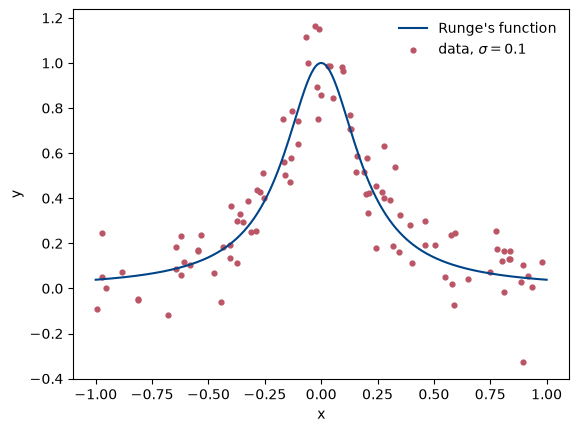

In [13]:
### Generate data and create quicklook
def generate_data(n=100, sigma=0.1, seed=2026):
    rng = np.random.default_rng(seed)     
    x = np.sort(rng.uniform(-1, 1, n))
    y = runge(x) + rng.normal(0, sigma, n)
    return x, y, n, sigma

x, y, n, sigma = generate_data()

xx = np.linspace(-1, 1, 400)
plt.plot(xx, runge(xx), color="#004488", label="Runge's function")
plt.scatter(x, y, s=12, color="#BB5566", label=rf"data, $\sigma={sigma}$")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(frameon=False)
plt.show()

## Part a): Ordinary Least Squares (OLS) for the Runge function
- OLS regression analysis using polynomials up to order 15
- explore dependence on number of data points
- and polynomial degree
- using MSE and R2

Plots:
- theta for increasing polynomial
- metrics as function of polynomial degree

Components:
- train-test split
- scaling/centering of data

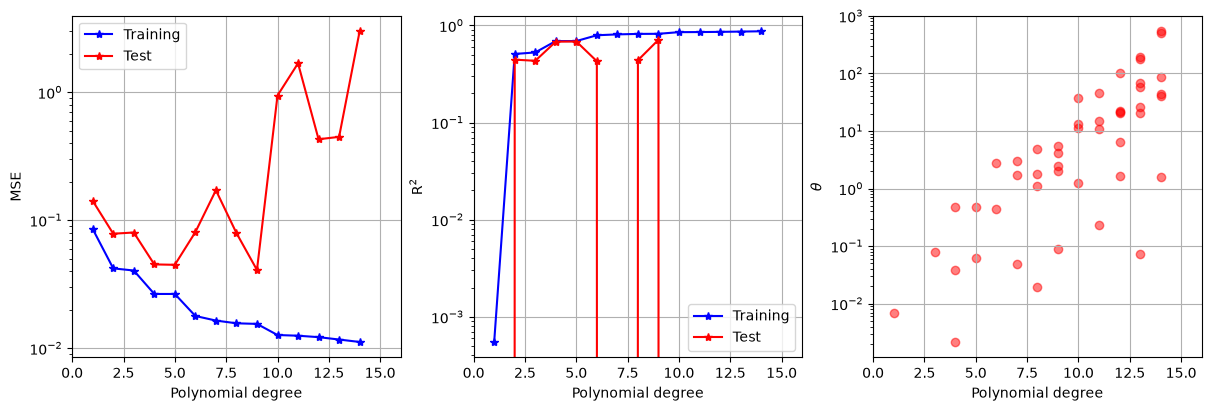

In [24]:
# Splitting data into test and train data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3,random_state=2026)

### collector function
def prepare_design_matrix(x_train, x_test, y_train, y_test, degree=5, intercept=True):
    """prepares design matrix and scales data"""
    # create design matrix
    X_train = design_matrix(x_train, degree=degree, intercept=intercept)
    X_test = design_matrix(x_test, degree=degree, intercept=intercept)

    # centering data by mean and scaling data by standard deviation
    X_train_norm = (X_train - np.mean(X_train, axis=0)) / np.std(X_train, axis=0)
    X_test_norm = (X_test - np.mean(X_test, axis=0)) / np.std(X_test, axis=0)
    y_train_norm = y_train - np.mean(y_train)
    y_test_norm = y_test - np.mean(y_test)
    return X_train_norm, X_test_norm, y_train_norm, y_test_norm




#Adding a model to perform OLS for polynomials up to degree 15
mse_train = []
mse_test = []
r2_train = []
r2_test = []
save_theta = []
for d in range(1,15):
    #Design matrix on the training data:
    X_train, X_test, y_train, y_test = prepare_design_matrix(x_train, x_test, y_train, y_test, degree=d, intercept=False)

    #calculate OLS theta
    theta = ols(X_train,y_train)
    save_theta.append(theta)

    #Calculate the MSE:
    mse_train.append(mean_squared_error(y_train, X_train @ theta))
    mse_test.append(mean_squared_error(y_test,  X_test @ theta))
    r2_train.append(r2_score(y_train, X_train @ theta))
    r2_test.append(r2_score(y_test,  X_test @ theta))


#Plotting the MSE as a function of polynomial degree
xx = np.linspace(1,14,14)

fig, ax = plt.subplots(1,3,figsize=(12,4), constrained_layout=True)

for a in ax:
    a.grid()
    a.set_xlim(0,16)
    a.set_yscale('log')

ax[0].plot(xx,mse_train,"b*-",label="Training")
ax[0].plot(xx,mse_test,"r*-",label="Test")
ax[0].set_ylabel("MSE")
ax[0].set_xlabel("Polynomial degree")
ax[0].legend()

ax[1].plot(xx,r2_train,"b*-",label="Training")
ax[1].plot(xx,r2_test,"r*-",label="Test")
ax[1].set_ylabel("R$^2$")
ax[1].set_xlabel("Polynomial degree")
ax[1].legend()

for i in range(len(save_theta)):
    ax[2].scatter(np.full(i+1, xx[i]), save_theta[i], color='r', alpha=0.5)
# ax[2].plot(xx,save_theta,"r*-",label="Test")
ax[2].set_ylabel(r"$\theta$")
ax[2].set_xlabel("Polynomial degree")


plt.show()


## Part b): Adding Ridge regression for the Runge function
- same analysis as a, but with Ridge
- for different values of penalty parameter lambda

Polynomial degree: 1
Minimum MSE is  0.0852454331582845 at lambda = 2.5118864315095823e-07 for training data
Minimum MSE is  0.1408697620662985 at lambda = 10000.0 for test data
Polynomial degree: 2
Minimum MSE is  0.0419864756226363 at lambda = 2.511886431509582e-08 for training data
Minimum MSE is  0.07832073165244044 at lambda = 1e-08 for test data
Polynomial degree: 3
Minimum MSE is  0.0403968803604171 at lambda = 6.30957344480193e-08 for training data
Minimum MSE is  0.0798943307575858 at lambda = 1.5848931924611174 for test data
Polynomial degree: 4
Minimum MSE is  0.026497232884738663 at lambda = 1e-08 for training data
Minimum MSE is  0.04509426766896332 at lambda = 1e-08 for test data
Polynomial degree: 5
Minimum MSE is  0.026493143402373014 at lambda = 1e-08 for training data
Minimum MSE is  0.044767790791748426 at lambda = 1e-08 for test data
Polynomial degree: 6
Minimum MSE is  0.017829076450046364 at lambda = 1e-08 for training data
Minimum MSE is  0.04047207755781056 at l

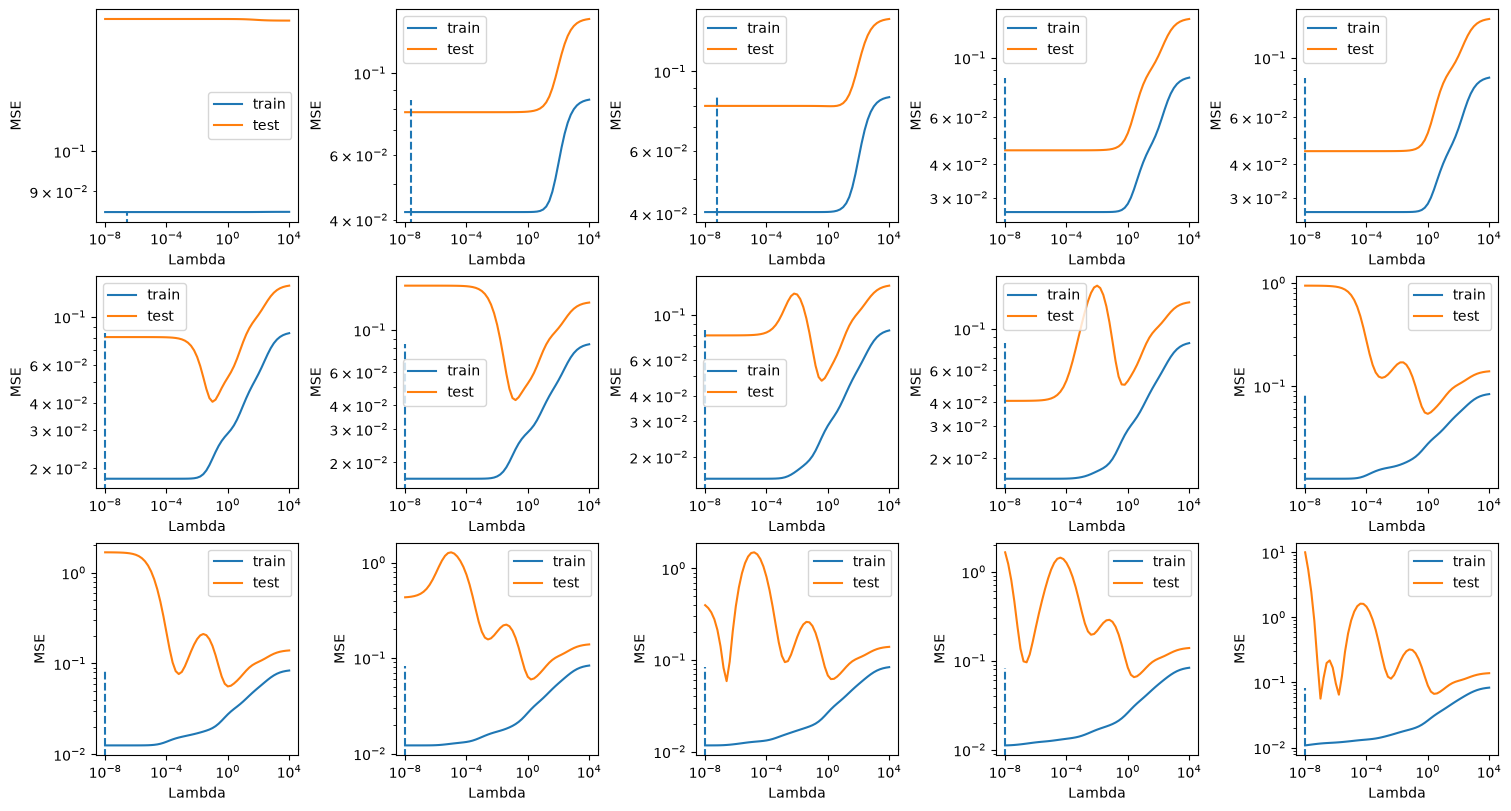

In [32]:
#Adding a model to perform OLS for polynomials up to degree 15
degs = np.arange(1,16)
fig = plt.figure(figsize=(15,8), constrained_layout=True)

for d in degs:
    ax = fig.add_subplot(3,5,d)
    #Design matrix on the training data:
    # X_train, X_test, y_train, y_test = prepare_design_matrix(x_train, x_test, y_train, y_test, degree=d, intercept=False)

    X_train = design_matrix(x_train, degree=d, intercept=False)
    X_test = design_matrix(x_test, degree=d, intercept=False)

    # centering data by mean and scaling data by standard deviation
    X_train_norm = (X_train - np.mean(X_train, axis=0)) / np.std(X_train, axis=0)
    X_test_norm = (X_test - np.mean(X_test, axis=0)) / np.std(X_test, axis=0)
    y_train_norm = y_train - np.mean(y_train)
    y_test_norm = y_test - np.mean(y_test)

    #Loop through different lambdas and calculate the Ridge regression and MSE
    lambdas = np.logspace(-8, 4, 61)
    mse_train = []
    mse_test = []
    for l in lambdas:
        #Theta from Ridge
        theta = Ridge(alpha=l, fit_intercept=False).fit(X_train_norm, y_train_norm).coef_
        #MSE for train and test data
        mse_train.append(mean_squared_error(y_train_norm, np.mean(y_test) + X_train_norm @ theta))
        mse_test.append(mean_squared_error(y_test_norm,  np.mean(y_test) + X_test_norm @ theta))


    #Plot the results
    ax.plot(lambdas,mse_train,label="train")
    ax.plot(lambdas,mse_test,label="test")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_ylabel("MSE")
    ax.set_xlabel("Lambda")
    ax.legend()
    ax.vlines(lambdas[np.argmin(mse_train)],ymin=0,ymax=np.max(mse_train),linestyle="--")

    #Finding the minimum MSE and at what lambda
    print(f"Polynomial degree: {d}")
    print("Minimum MSE is ",np.min(mse_train), "at lambda =", lambdas[np.argmin(mse_train)], "for training data")
    print("Minimum MSE is ",np.min(mse_test), "at lambda =", lambdas[np.argmin(mse_test)], "for test data")